# Solvent Accessibility Analysis (SASA & RSA) for PDB Structures

This notebook calculates Solvent Accessible Surface Area (SASA) and Relative Solvent Accessibility (RSA) for all sites in PDB files, both with and without antigen present.

In [1]:
import os
import random
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

# BioPython imports for PDB handling and DSSP
from Bio.PDB import PDBParser, PDBIO, Select
from Bio.PDB.DSSP import DSSP
from Bio import PDB
from Bio.SeqUtils import seq1

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

## Helper Classes and Functions

Based on the reference code from `dnsm-experiments-1/dnsmex/dms_viz.py`, we'll create classes for handling SASA calculations.

In [2]:
class AntibodyChainSelector(Select):
    """Select specific chains from PDB structure."""
    
    def __init__(self, chain_ids):
        self.chain_ids = chain_ids if isinstance(chain_ids, list) else [chain_ids]
    
    def accept_chain(self, chain):
        return chain.id in self.chain_ids


class AntigenRemover(Select):
    """Remove antigen chains, keeping only antibody chains."""
    
    def __init__(self, antibody_chains):
        self.antibody_chains = antibody_chains if isinstance(antibody_chains, list) else [antibody_chains]
    
    def accept_chain(self, chain):
        return chain.id in self.antibody_chains

In [9]:
class SASACalculator:
    """Calculate SASA and RSA for PDB structures."""
    
    def __init__(self, temp_dir="_temp_sasa"):
        self.temp_dir = Path(temp_dir)
        self.temp_dir.mkdir(exist_ok=True)
        
        # Standard amino acid volumes for RSA calculation (Angstrom squared)
        # From Chothia (1976) and other sources
        self.aa_max_asa = {
            'A': 129.0, 'R': 274.0, 'N': 195.0, 'D': 193.0,
            'C': 167.0, 'Q': 225.0, 'E': 223.0, 'G': 104.0,
            'H': 224.0, 'I': 197.0, 'L': 201.0, 'K': 236.0,
            'M': 224.0, 'F': 240.0, 'P': 159.0, 'S': 155.0,
            'T': 172.0, 'W': 285.0, 'Y': 263.0, 'V': 174.0
        }
    
    def calculate_sasa_with_antigen(self, pdb_path, antibody_chains, site_range=None):
        """Calculate SASA for antibody with antigen present."""
        return self._calculate_sasa(pdb_path, antibody_chains, with_antigen=True, site_range=site_range)
    
    def calculate_sasa_without_antigen(self, pdb_path, antibody_chains, site_range=None):
        """Calculate SASA for antibody without antigen (antibody chains only)."""
        return self._calculate_sasa(pdb_path, antibody_chains, with_antigen=False, site_range=site_range)
    
    def _calculate_sasa(self, pdb_path, antibody_chains, with_antigen=True, site_range=None):
        """Internal method to calculate SASA."""
        parser = PDBParser(PERMISSIVE=True, QUIET=True)
        structure = parser.get_structure('pdb', pdb_path)
        model = structure[0]
        
        # Create temporary PDB file
        temp_id = random.randint(10000, 99999)
        temp_pdb_path = self.temp_dir / f"temp_{temp_id}.pdb"
        
        try:
            io = PDBIO()
            io.set_structure(structure)
            
            if with_antigen:
                # Keep all chains
                io.save(str(temp_pdb_path))
            else:
                # Keep only antibody chains
                io.save(str(temp_pdb_path), AntigenRemover(antibody_chains))
            
            # Reload the filtered structure
            filtered_structure = parser.get_structure('filtered', str(temp_pdb_path))
            filtered_model = filtered_structure[0]
            
            # Calculate DSSP
            dssp = DSSP(filtered_model, str(temp_pdb_path), dssp="mkdssp", acc_array="Wilke", file_type="PDB")
            
            # Extract data for antibody chains only
            sasa_data = []
            
            for key in dssp.keys():
                chain_id, res_id = key
                
                # Only process antibody chains
                if chain_id not in antibody_chains:
                    continue
                
                # Extract residue information
                residue_num = res_id[1]
                insertion_code = res_id[2].strip()
                
                # Apply site range filter if specified
                if site_range and (residue_num < site_range[0] or residue_num > site_range[1]):
                    continue
                
                # Get DSSP data
                aa = dssp[key][1]  # Amino acid
                sasa = dssp[key][3]  # Accessible surface area
                
                # Calculate RSA
                max_asa = self.aa_max_asa.get(aa, 200.0)  # Default if unknown AA
                rsa = sasa / max_asa if max_asa > 0 else 0.0
                
                # Get CA coordinates if available
                ca_coord = None
                try:
                    residue = filtered_model[chain_id][res_id]
                    if "CA" in residue:
                        ca_coord = tuple(residue["CA"].coord)
                except:
                    pass
                
                sasa_data.append({
                    'chain_id': chain_id,
                    'residue_number': residue_num,
                    'insertion_code': insertion_code,
                    'amino_acid': aa,
                    'sasa': sasa,
                    'rsa': rsa,
                    'ca_coordinates': ca_coord,
                    'with_antigen': with_antigen
                })
            
            return pd.DataFrame(sasa_data)
            
        finally:
            # Clean up temporary file
            if temp_pdb_path.exists():
                temp_pdb_path.unlink()
    
    def compare_sasa(self, pdb_path, antibody_chains, site_range=None):
        """Calculate SASA both with and without antigen and compare."""
        
        sasa_with = self.calculate_sasa_with_antigen(pdb_path, antibody_chains, site_range)
        sasa_without = self.calculate_sasa_without_antigen(pdb_path, antibody_chains, site_range)
        
        # Merge the results
        comparison = pd.merge(
            sasa_with[['chain_id', 'residue_number', 'insertion_code', 'amino_acid', 'sasa', 'rsa', 'ca_coordinates']],
            sasa_without[['chain_id', 'residue_number', 'insertion_code', 'sasa', 'rsa']],
            on=['chain_id', 'residue_number', 'insertion_code'],
            suffixes=('_with_antigen', '_without_antigen'),
            how='outer'
        )
        
        # Calculate differences
        comparison['sasa_difference'] = comparison['sasa_with_antigen'] - comparison['sasa_without_antigen']
        comparison['rsa_difference'] = comparison['rsa_with_antigen'] - comparison['rsa_without_antigen']
        
        # Calculate relative change
        comparison['sasa_relative_change'] = (
            comparison['sasa_difference'] / comparison['sasa_without_antigen']
        ).replace([np.inf, -np.inf], np.nan)
        
        comparison['rsa_relative_change'] = (
            comparison['rsa_difference'] / comparison['rsa_without_antigen']
        ).replace([np.inf, -np.inf], np.nan)
        
        return comparison
    
    def cleanup(self):
        """Remove temporary directory."""
        import shutil
        if self.temp_dir.exists():
            shutil.rmtree(self.temp_dir)

## Batch Processing Multiple PDB Files

Function to process multiple PDB files at once:

In [15]:
def process_pdb_directory(pdb_directory, antibody_chains=['H', 'L'], site_range=None, output_file=None):
    """
    Process all PDB files in a directory.
    
    Parameters:
    -----------
    pdb_directory : str or Path
        Directory containing PDB files
    antibody_chains : list
        List of chain IDs for antibody chains (default: ['H', 'L'])
    site_range : tuple or None
        Range of residue numbers to include (min, max) or None for all
    output_file : str or None
        Output CSV file path or None to return DataFrame only
    
    Returns:
    --------
    pd.DataFrame
        Combined results for all PDB files
    """
    pdb_dir = Path(pdb_directory)
    pdb_files = list(pdb_dir.glob("*.pdb"))
    pdb_files = pdb_files[:30]
    
    if not pdb_files:
        print(f"No PDB files found in {pdb_dir}")
        return pd.DataFrame()
    
    calculator = SASACalculator()
    all_results = []
    
    print(f"Processing {len(pdb_files)} PDB files...")
    
    for pdb_file in tqdm(pdb_files, desc="Processing PDBs"):
        try:
            pdb_id = pdb_file.stem
            results = calculator.compare_sasa(str(pdb_file), antibody_chains, site_range)
            results['pdb_id'] = pdb_id
            all_results.append(results)
            
        except Exception as e:
            print(f"Error processing {pdb_file.name}: {str(e)}")
            continue
    
    # Cleanup temporary files
    calculator.cleanup()
    
    if not all_results:
        print("No files were successfully processed")
        return pd.DataFrame()
    
    # Combine all results
    combined_results = pd.concat(all_results, ignore_index=True)
    
    # Reorder columns for better readability
    column_order = [
        'pdb_id', 'chain_id', 'residue_number', 'insertion_code', 'amino_acid',
        'sasa_with_antigen', 'sasa_without_antigen', 'sasa_difference', 'sasa_relative_change',
        'rsa_with_antigen', 'rsa_without_antigen', 'rsa_difference', 'rsa_relative_change',
        'ca_coordinates'
    ]
    
    combined_results = combined_results.reindex(columns=column_order)
    
    # Save to file if requested
    if output_file:
        combined_results.to_csv(output_file, index=False)
        print(f"Results saved to {output_file}")
    
    return combined_results

## Analysis and Visualization Functions

In [16]:
def analyze_sasa_results(df, save_plots=True, output_dir="_output"):
    """
    Analyze and visualize SASA calculation results.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results from SASA calculations
    save_plots : bool
        Whether to save plots to files
    output_dir : str
        Directory to save plots
    """
    
    if save_plots:
        os.makedirs(output_dir, exist_ok=True)
    
    # Summary statistics
    print("=== SASA Analysis Summary ===")
    print(f"Total residues analyzed: {len(df)}")
    print(f"Unique PDB structures: {df['pdb_id'].nunique()}")
    print(f"Chain distribution:")
    print(df['chain_id'].value_counts())
    
    # SASA statistics
    print("\n=== SASA Statistics ===")
    print(f"Mean SASA with antigen: {df['sasa_with_antigen'].mean():.2f} A^2")
    print(f"Mean SASA without antigen: {df['sasa_without_antigen'].mean():.2f} A^2")
    print(f"Mean SASA difference: {df['sasa_difference'].mean():.2f} A^2")
    
    # RSA statistics
    print("\n=== RSA Statistics ===")
    print(f"Mean RSA with antigen: {df['rsa_with_antigen'].mean():.3f}")
    print(f"Mean RSA without antigen: {df['rsa_without_antigen'].mean():.3f}")
    print(f"Mean RSA difference: {df['rsa_difference'].mean():.3f}")
    
    # Identify most affected residues
    print("\n=== Most Affected Residues (by SASA difference) ===")
    most_affected = df.nlargest(10, 'sasa_difference')[['pdb_id', 'chain_id', 'residue_number', 
                                                        'amino_acid', 'sasa_difference', 'rsa_difference']]
    print(most_affected.to_string(index=False))
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('SASA Analysis Results', fontsize=16, fontweight='bold')
    
    # Plot 1: SASA with vs without antigen
    axes[0, 0].scatter(df['sasa_without_antigen'], df['sasa_with_antigen'], alpha=0.6)
    axes[0, 0].plot([0, df['sasa_without_antigen'].max()], [0, df['sasa_without_antigen'].max()], 'r--', alpha=0.8)
    axes[0, 0].set_xlabel('SASA without antigen (A^2)')
    axes[0, 0].set_ylabel('SASA with antigen (A^2)')
    axes[0, 0].set_title('SASA: With vs Without Antigen')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: SASA difference distribution
    axes[0, 1].hist(df['sasa_difference'], bins=50, alpha=0.7, edgecolor='black')
    axes[0, 1].axvline(0, color='red', linestyle='--', alpha=0.8)
    axes[0, 1].set_xlabel('SASA Difference (A^2)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of SASA Differences')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: RSA with vs without antigen
    axes[1, 0].scatter(df['rsa_without_antigen'], df['rsa_with_antigen'], alpha=0.6)
    axes[1, 0].plot([0, df['rsa_without_antigen'].max()], [0, df['rsa_without_antigen'].max()], 'r--', alpha=0.8)
    axes[1, 0].set_xlabel('RSA without antigen')
    axes[1, 0].set_ylabel('RSA with antigen')
    axes[1, 0].set_title('RSA: With vs Without Antigen')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: RSA difference by chain
    if 'chain_id' in df.columns and df['chain_id'].nunique() > 1:
        df.boxplot(column='rsa_difference', by='chain_id', ax=axes[1, 1])
        axes[1, 1].set_title('RSA Difference by Chain')
        axes[1, 1].set_xlabel('Chain ID')
        axes[1, 1].set_ylabel('RSA Difference')
    else:
        axes[1, 1].hist(df['rsa_difference'], bins=50, alpha=0.7, edgecolor='black')
        axes[1, 1].axvline(0, color='red', linestyle='--', alpha=0.8)
        axes[1, 1].set_xlabel('RSA Difference')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Distribution of RSA Differences')
    
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_plots:
        plt.savefig(f"{output_dir}/sasa_analysis_plots.png", dpi=300, bbox_inches='tight')
        print(f"\nPlots saved to {output_dir}/sasa_analysis_plots.png")
    
    plt.show()
    
    return df.describe()

## Example Workflow

Uncomment and modify the code below to run analysis on your PDB files:

Available PDB numbering schemes: ['opig-chothia', 'rcsb', 'opig-imgt']
Selected scheme: opig-chothia
PDB directory: /fh/fast/matsen_e/shared/bcr-mut-sel/sabdab/pdb-db/pdb/opig-chothia
Found 8120 PDB files
First few files: ['7k63.pdb', '8hpf.pdb', '7ew3.pdb', '4qnp.pdb', '7tyh.pdb']
Starting batch processing...
Processing 30 PDB files...


Processing PDBs:   0%|          | 0/30 [00:00<?, ?it/s]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
Processing PDBs:   3%|▎         | 1/30 [00:03<01:29,  3.10s/it]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
Processing PDBs:   7%|▋         | 2/30 [00:05<01:19,  2.86s/it]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/s

Error processing 7ew3.pdb: 0


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
Processing PDBs:  13%|█▎        | 4/30 [00:10<01:07,  2.60s/it]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
Processing PDBs:  17%|█▋        | 5/30 [00:12<00:55,  2.22s/it]

Error processing 7tyh.pdb: 0


...

Error processing 8hmv.pdb: 0


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
Processing PDBs:  80%|████████  | 24/30 [01:15<00:15,  2.60s/it]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
Processing PDBs:  83%|████████▎ | 25/30 [01:18<00:13,  2.65s/it]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse 

Error processing 4dk3.pdb: 0


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
Processing PDBs:  97%|█████████▋| 29/30 [01:28<00:02,  2.51s/it]/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

  warnings.warn(err)
Processing PDBs: 100%|██████████| 30/30 [01:29<00:00,  2.99s/it]


Error processing 4gft.pdb: 0
Results saved to _output/sasa_results.csv

Processed 6702 residues from 18 structures
=== SASA Analysis Summary ===
Total residues analyzed: 6702
Unique PDB structures: 18
Chain distribution:
chain_id
H    3803
L    2899
Name: count, dtype: int64

=== SASA Statistics ===
Mean SASA with antigen: 0.24 A^2
Mean SASA without antigen: 0.26 A^2
Mean SASA difference: -0.03 A^2

=== RSA Statistics ===
Mean RSA with antigen: 0.001
Mean RSA without antigen: 0.002
Mean RSA difference: -0.000

=== Most Affected Residues (by SASA difference) ===
pdb_id chain_id  residue_number amino_acid  sasa_difference  rsa_difference
  7k63        H              30          K              0.0             0.0
  7k63        H              31          R              0.0             0.0
  7k63        H              32          S              0.0             0.0
  7k63        H              33          R              0.0             0.0
  7k63        H              34          K          

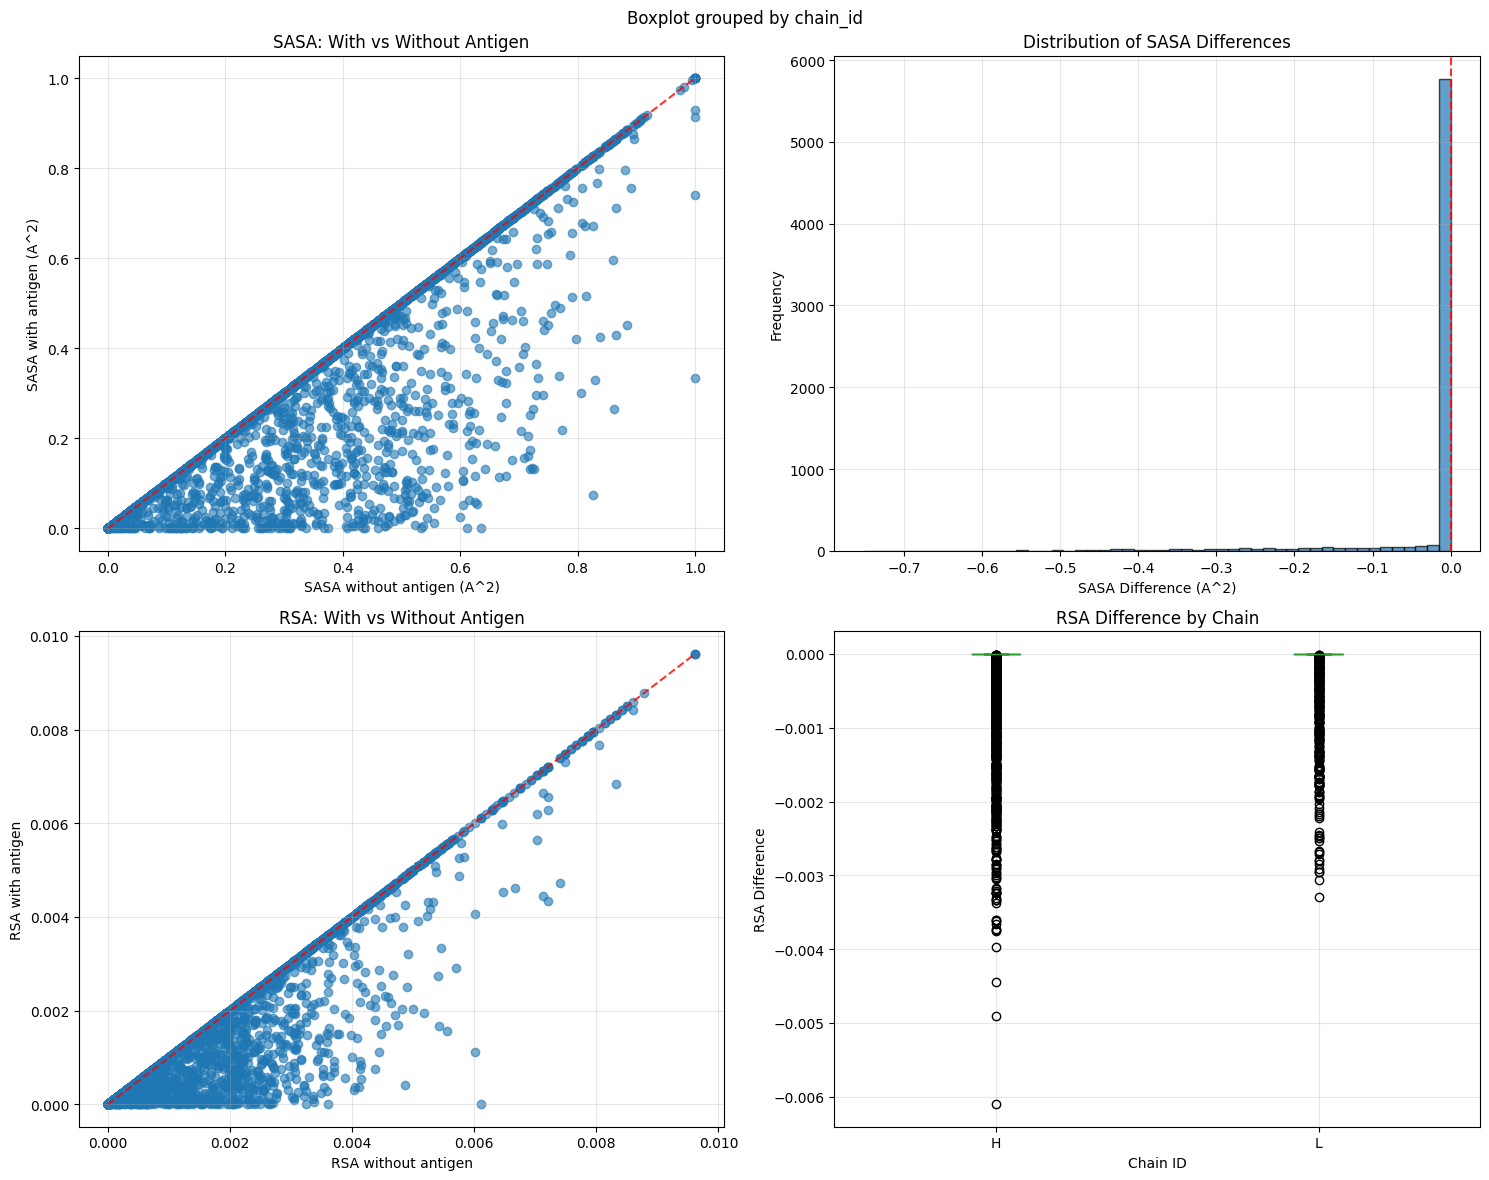


=== Summary Statistics ===
       residue_number  sasa_with_antigen  sasa_without_antigen  \
count     6702.000000        6702.000000           6702.000000   
mean       123.722919           0.235788              0.263493   
std         85.981782           0.220864              0.227291   
min          1.000000           0.000000              0.000000   
25%         57.000000           0.037500              0.050761   
50%        115.000000           0.179860              0.226744   
75%        176.000000           0.387097              0.426009   
max        524.000000           1.000000              1.000000   

       sasa_difference  sasa_relative_change  rsa_with_antigen  \
count      6702.000000           6048.000000       6702.000000   
mean         -0.027705             -0.089471          0.001388   
std           0.086815              0.237854          0.001459   
min          -0.751244             -1.000000          0.000000   
25%           0.000000              0.000000   

NameError: name 'generate_report' is not defined

In [17]:
# Example workflow - configured for SAbDab PDB directory

import os
os.environ['LIBCIFPP_DATA_DIR'] = '/home/nharel/miniforge3/envs/netam_env/share/libcifpp'


# Main SAbDab PDB directory
SABDAB_PDB_DIR = "/fh/fast/matsen_e/shared/bcr-mut-sel/sabdab/pdb-db"

# Check available numbering schemes
import os
if os.path.exists(SABDAB_PDB_DIR):
    pdb_subdir = os.path.join(SABDAB_PDB_DIR, "pdb")
    if os.path.exists(pdb_subdir):
        schemes = [d for d in os.listdir(pdb_subdir) if os.path.isdir(os.path.join(pdb_subdir, d))]
        print(f"Available PDB numbering schemes: {schemes}")
        
        # Use the first available scheme or specify one
        if schemes:
            selected_scheme = schemes[0]  # Or specify: 'rcsb', 'opig-imgt', etc.
            pdb_directory = os.path.join(pdb_subdir, selected_scheme)
            print(f"Selected scheme: {selected_scheme}")
            print(f"PDB directory: {pdb_directory}")
            
            # Count available PDB files
            pdb_files = [f for f in os.listdir(pdb_directory) if f.endswith('.pdb')]
            print(f"Found {len(pdb_files)} PDB files")
            
            if len(pdb_files) > 0:
                print(f"First few files: {pdb_files[:5]}")
        else:
            print("No PDB subdirectories found")
    else:
        print("PDB subdirectory not found")
else:
    print(f"SAbDab PDB directory not found: {SABDAB_PDB_DIR}")

# Uncomment and run the analysis below:

# 1. Set up paths
# Choose a numbering scheme: 'rcsb', 'opig-imgt', or 'opig-chothia'
scheme = 'opig-imgt'  # Change as needed
pdb_directory = f"/fh/fast/matsen_e/shared/bcr-mut-sel/sabdab/pdb-db/pdb/{scheme}"
output_file = "_output/sasa_results.csv"

# 2. Define antibody chains (modify as needed for your structures)
antibody_chains = ['H', 'L']  # Heavy and Light chains

# 3. Optional: restrict analysis to specific residue range or subset of files
# site_range = (1, 120)  # Uncomment to analyze only residues 1-120
site_range = None  # Analyze all residues

# For testing, you might want to process just a few files first:
# import os
# test_files = [f for f in os.listdir(pdb_directory) if f.endswith('.pdb')][:5]
# print(f"Testing with {len(test_files)} files: {test_files}")

# 4. Process all PDB files (or test files)
print("Starting batch processing...")
results = process_pdb_directory(
    pdb_directory=pdb_directory,
    antibody_chains=antibody_chains,
    site_range=site_range,
    output_file=output_file
)

# 5. Analyze results
if len(results) > 0:
    print(f"\nProcessed {len(results)} residues from {results['pdb_id'].nunique()} structures")
    
    # Perform analysis and create visualizations
    summary_stats = analyze_sasa_results(results, save_plots=True, output_dir="_output")
    
    # Display summary statistics
    print("\n=== Summary Statistics ===")
    print(summary_stats)
    
    # Generate comprehensive report
    generate_report(results, "_output/sasa_analysis_report.txt")
    
    # Identify interface residues
    interface_residues = identify_interface_residues(results, sasa_threshold=10.0, rsa_threshold=0.1)
    print(f"\nIdentified {interface_residues['potential_interface'].sum()} potential interface residues")
else:
    print("No results to analyze.")

print("PDB directory analysis complete. Uncomment the analysis code above to run SASA calculations.")

In [ ]:
results

,pdb_id,chain_id,residue_number,insertion_code,amino_acid,sasa_with_antigen,sasa_without_antigen,sasa_difference,sasa_relative_change,rsa_with_antigen,rsa_without_antigen,rsa_difference,rsa_relative_change,ca_coordinates
0,7k63,H,30,,K,1.000000,1.000000,0.0,0.0,0.004237,0.004237,0.0,0.0,"(153.152, 195.595, 206.362)"
1,7k63,H,31,,R,0.682482,0.682482,0.0,0.0,0.002491,0.002491,0.0,0.0,"(156.236, 195.096, 204.203)"
2,7k63,H,32,,S,0.600000,0.600000,0.0,0.0,0.003871,0.003871,0.0,0.0,"(159.099, 192.646, 204.737)"
3,7k63,H,33,,R,0.791971,0.791971,0.0,0.0,0.002890,0.002890,0.0,0.0,"(162.784, 192.41, 203.856)"
4,7k63,H,34,,K,0.741525,0.741525,0.0,0.0,0.003142,0.003142,0.0,0.0,"(163.626, 191.038, 200.387)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2287,3vi3,L,230,,N,0.246154,0.246154,0.0,0.0,0.001262,0.001262,0.0,0.0,"(-64.51, -73.428, 49.865)"
2288,3vi3,L,231,,R,0.284672,0.284672,0.0,0.0,0.001039,0.001039,0.0,0.0,"(-62.959, -70.716, 52.0)"
2289,3vi3,L,232,,N,0.523077,0.523077,0.0,0.0,0.002682,0.002682,0.0,0.0,"(-62.77, -73.216, 54.9)"
2290,3vi3,L,233,,E,0.520179,0.520179,0.0,0.0,0.002333,0.002333,0.0,0.0,"(-60.976, -76.425, 53.823)"


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128],
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '10'),
  Text(10, 0, '

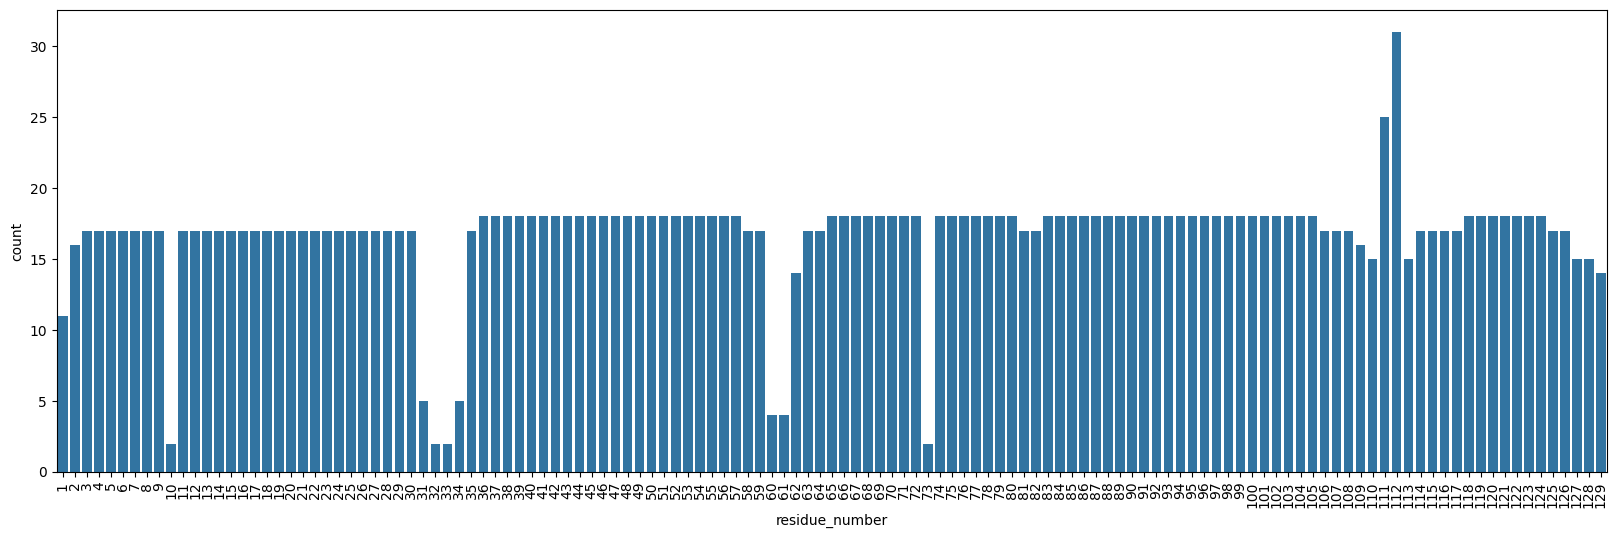

In [18]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.countplot(results[(results.chain_id == 'H') & (results.residue_number <= 129)], x='residue_number',ax=ax)
# rotate x labels for better readability
plt.xticks(rotation=90)


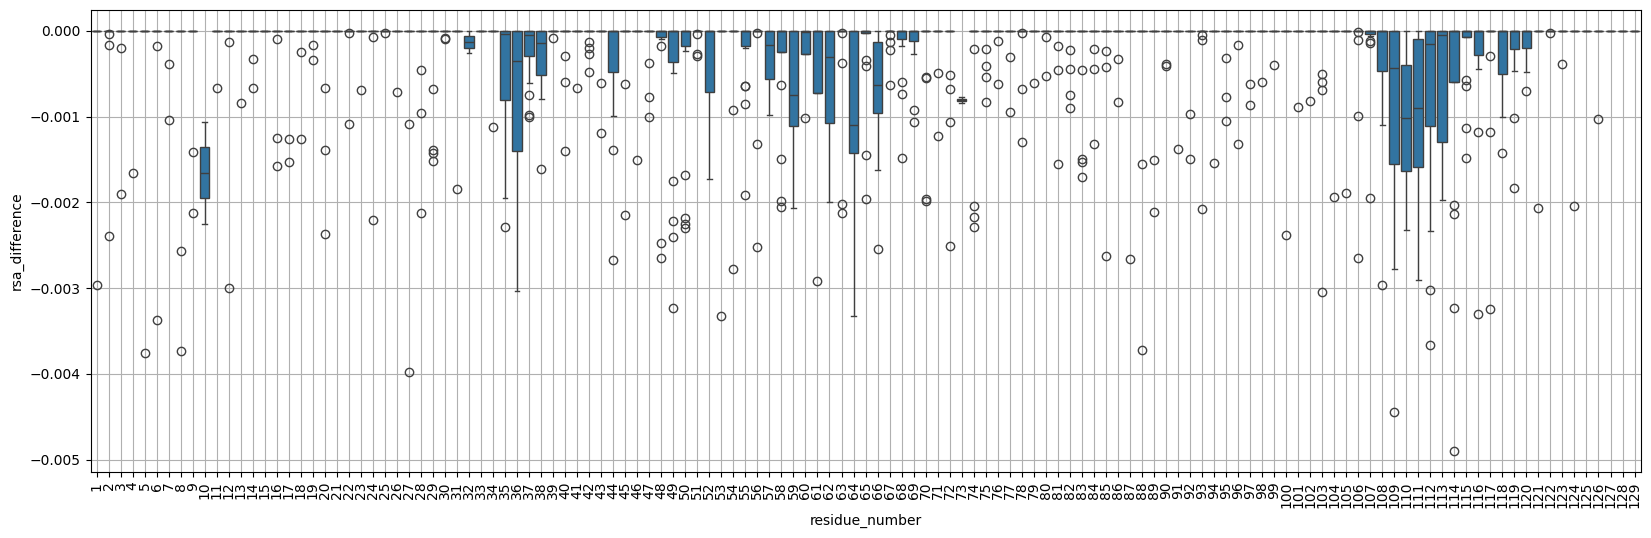

In [19]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(results[(results.chain_id == 'H')  & (results.residue_number <= 129)], x='residue_number', y='rsa_difference', ax=ax)
# rotate x labels for better readability
plt.xticks(rotation=90)
ax.grid()


## Single Structure Analysis

For analyzing a single PDB structure:

In [8]:
def analyze_single_structure(pdb_file, antibody_chains=['H', 'L'], site_range=None, show_plots=True):
    """
    Analyze a single PDB structure.
    
    Parameters:
    -----------
    pdb_file : str
        Path to PDB file
    antibody_chains : list
        List of antibody chain IDs
    site_range : tuple or None
        Range of residues to analyze
    show_plots : bool
        Whether to display plots
        
    Returns:
    --------
    pd.DataFrame
        SASA analysis results
    """
    
    calculator = SASACalculator()
    
    try:
        print(f"Analyzing {pdb_file}...")
        results = calculator.compare_sasa(pdb_file, antibody_chains, site_range)
        pdb_id = Path(pdb_file).stem
        results['pdb_id'] = pdb_id
        
        print(f"\nAnalyzed {len(results)} residues")
        print(f"Mean SASA difference: {results['sasa_difference'].mean():.2f} A^2")
        print(f"Mean RSA difference: {results['rsa_difference'].mean():.3f}")
        
        # Find most affected residues
        most_buried = results.nsmallest(5, 'sasa_difference')
        most_exposed = results.nlargest(5, 'sasa_difference')
        
        print("\nMost buried by antigen (negative SASA difference):")
        print(most_buried[['chain_id', 'residue_number', 'amino_acid', 'sasa_difference']].to_string(index=False))
        
        print("\nMost exposed by antigen (positive SASA difference):")
        print(most_exposed[['chain_id', 'residue_number', 'amino_acid', 'sasa_difference']].to_string(index=False))
        
        if show_plots:
            # Create residue-level plot
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
            
            # Plot SASA difference by residue number
            for chain in results['chain_id'].unique():
                chain_data = results[results['chain_id'] == chain]
                ax1.plot(chain_data['residue_number'], chain_data['sasa_difference'], 
                        'o-', label=f'Chain {chain}', alpha=0.7)
            
            ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
            ax1.set_xlabel('Residue Number')
            ax1.set_ylabel('SASA Difference (A^2)')
            ax1.set_title(f'SASA Changes Along Sequence\n{pdb_id}')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # Plot RSA difference by residue number
            for chain in results['chain_id'].unique():
                chain_data = results[results['chain_id'] == chain]
                ax2.plot(chain_data['residue_number'], chain_data['rsa_difference'], 
                        'o-', label=f'Chain {chain}', alpha=0.7)
            
            ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
            ax2.set_xlabel('Residue Number')
            ax2.set_ylabel('RSA Difference')
            ax2.set_title(f'RSA Changes Along Sequence\n{pdb_id}')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
        
        return results
        
    except Exception as e:
        print(f"Error analyzing {pdb_file}: {str(e)}")
        return pd.DataFrame()
    
    finally:
        calculator.cleanup()

# Example usage:
# results = analyze_single_structure("path/to/structure.pdb", antibody_chains=['H', 'L'])

Testing with first available file: 7k63.pdb
Analyzing /fh/fast/matsen_e/shared/bcr-mut-sel/sabdab/pdb-db/pdb/opig-imgt/7k63.pdb...
Analyzing /fh/fast/matsen_e/shared/bcr-mut-sel/sabdab/pdb-db/pdb/opig-imgt/7k63.pdb...


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/Bio/PDB/DSSP.py:199: UserWarning: parse error at line 1: This file does not seem to be an mmCIF file

Configuration error:

The attempt to retrieve compound information for "LYS" failed.

This information is searched for in a CCD file called components.cif or
components.cif.gz which should be located in one of the following directories:

"/home/nharel/miniforge3/envs/netam_env/share/libcifpp"

(Note that you can add a directory to the search paths by setting the 
LIBCIFPP_DATA_DIR environmental variable)

On Linux an optional cron script might have been installed that automatically updates
components.cif and mmCIF dictionary files. This script only works when the file
libcifpp.conf contains an uncommented line with the text:

update=true

If you do not have a working cron script, you can manually update the files
in /var/cache/libcifpp using the following commands:

curl -o /home/nharel/miniforge3/envs/netam_env/var/ca


Analyzed 95 residues
Mean SASA difference: -0.20 A^2
Mean RSA difference: -0.001

Most buried by antigen (negative SASA difference):
chain_id  residue_number amino_acid  sasa_difference
       H              61          I        -0.573604
       H             121          Y        -0.543726
       H             106          L        -0.532338
       H              64          S        -0.516129
       H             103          P        -0.484277

Most exposed by antigen (positive SASA difference):
chain_id  residue_number amino_acid  sasa_difference
       H              30          K              0.0
       H              31          R              0.0
       H              32          S              0.0
       H              33          R              0.0
       H              34          K              0.0


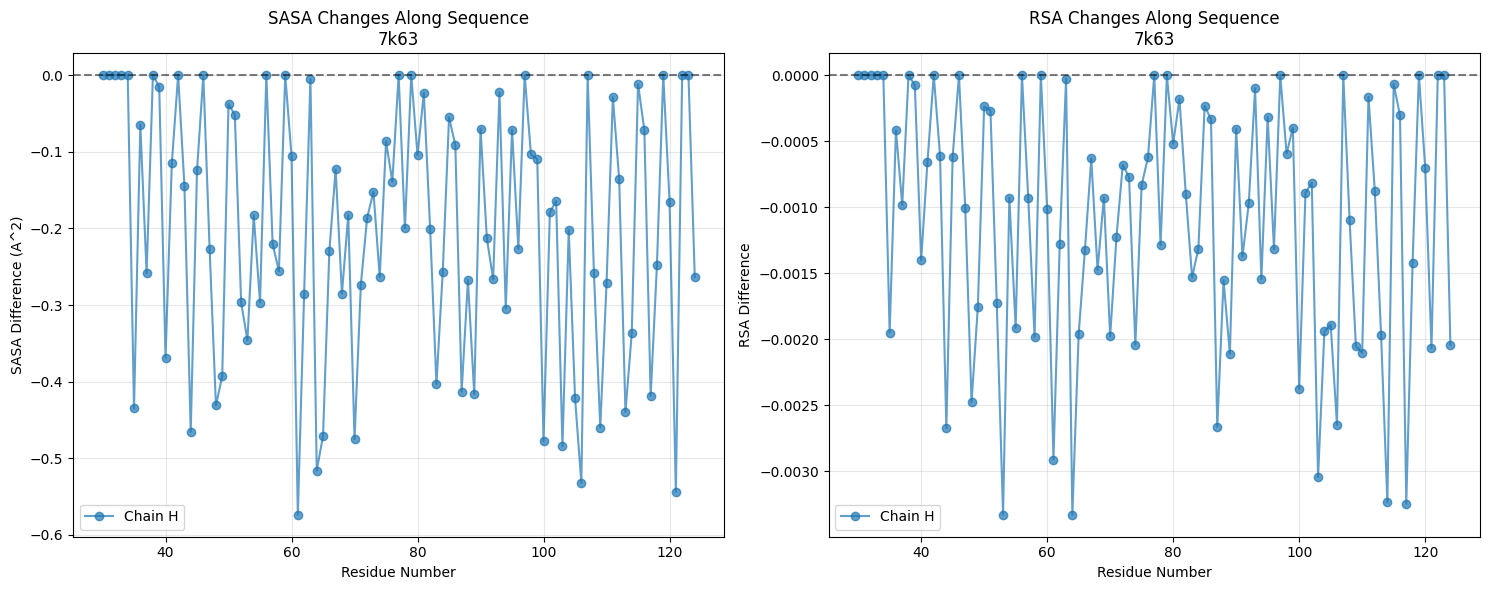

Single file testing function ready. Uncomment the line above to test.


In [11]:
# Test with a single PDB file from SAbDab
# This cell helps you test the SASA calculation on one file before running batch processing

# Function to test single file from SAbDab directory
def test_single_sabdab_file(scheme='rcsb', pdb_filename=None, antibody_chains=['H', 'L']):
    """
    Test SASA calculation on a single file from the SAbDab directory.
    
    Parameters:
    -----------
    scheme : str
        Numbering scheme ('rcsb', 'opig-imgt', or 'opig-chothia')
    pdb_filename : str or None
        Specific PDB filename to test, or None to use the first available
    antibody_chains : list
        Antibody chain IDs to analyze
    """
    
    pdb_directory = f"/fh/fast/matsen_e/shared/bcr-mut-sel/sabdab/pdb-db/pdb/{scheme}"
    
    if not os.path.exists(pdb_directory):
        print(f"Directory not found: {pdb_directory}")
        return None
    
    # Get available PDB files
    pdb_files = [f for f in os.listdir(pdb_directory) if f.endswith('.pdb')]
    
    if not pdb_files:
        print(f"No PDB files found in {pdb_directory}")
        return None
    
    # Select file to test
    if pdb_filename is None:
        test_file = pdb_files[0]
        print(f"Testing with first available file: {test_file}")
    else:
        if pdb_filename in pdb_files:
            test_file = pdb_filename
            print(f"Testing with specified file: {test_file}")
        else:
            print(f"File {pdb_filename} not found. Available files: {pdb_files[:10]}...")
            return None
    
    pdb_path = os.path.join(pdb_directory, test_file)
    
    # Run analysis
    print(f"Analyzing {pdb_path}...")
    results = analyze_single_structure(
        pdb_path, 
        antibody_chains=antibody_chains, 
        site_range=None,
        show_plots=True
    )
    
    return results

# Uncomment to test with a single file:
results = test_single_sabdab_file(scheme='opig-imgt', antibody_chains=['H', 'L'])

print("Single file testing function ready. Uncomment the line above to test.")

## Utility Functions

In [ ]:
def identify_interface_residues(df, sasa_threshold=10.0, rsa_threshold=0.1):
    """
    Identify potential interface residues based on SASA/RSA changes.
    
    Parameters:
    -----------
    df : pd.DataFrame
        SASA analysis results
    sasa_threshold : float
        Minimum SASA change to consider significant (A^2)
    rsa_threshold : float
        Minimum RSA change to consider significant
        
    Returns:
    --------
    pd.DataFrame
        Interface residues with significance flags
    """
    
    interface_df = df.copy()
    
    # Flag significant changes
    interface_df['significant_sasa_change'] = (
        abs(interface_df['sasa_difference']) > sasa_threshold
    )
    
    interface_df['significant_rsa_change'] = (
        abs(interface_df['rsa_difference']) > rsa_threshold
    )
    
    # Identify buried vs exposed
    interface_df['buried_by_antigen'] = (
        interface_df['sasa_difference'] < -sasa_threshold
    )
    
    interface_df['exposed_by_antigen'] = (
        interface_df['sasa_difference'] > sasa_threshold
    )
    
    # Mark potential interface residues
    interface_df['potential_interface'] = (
        interface_df['significant_sasa_change'] | 
        interface_df['significant_rsa_change']
    )
    
    return interface_df


def generate_report(df, output_file="_output/sasa_analysis_report.txt"):
    """
    Generate a comprehensive text report of the analysis.
    """
    
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    
    with open(output_file, 'w') as f:
        f.write("SOLVENT ACCESSIBILITY ANALYSIS REPORT\n")
        f.write("=" * 50 + "\n\n")
        
        # Overall statistics
        f.write("OVERALL STATISTICS\n")
        f.write("-" * 20 + "\n")
        f.write(f"Total residues analyzed: {len(df)}\n")
        f.write(f"Unique PDB structures: {df['pdb_id'].nunique()}\n")
        f.write(f"Chains analyzed: {', '.join(df['chain_id'].unique())}\n\n")
        
        # SASA statistics
        f.write("SASA STATISTICS\n")
        f.write("-" * 15 + "\n")
        f.write(f"Mean SASA with antigen: {df['sasa_with_antigen'].mean():.2f} ± {df['sasa_with_antigen'].std():.2f} A^2\n")
        f.write(f"Mean SASA without antigen: {df['sasa_without_antigen'].mean():.2f} ± {df['sasa_without_antigen'].std():.2f} A^2\n")
        f.write(f"Mean SASA difference: {df['sasa_difference'].mean():.2f} ± {df['sasa_difference'].std():.2f} A^2\n")
        f.write(f"SASA difference range: {df['sasa_difference'].min():.2f} to {df['sasa_difference'].max():.2f} A^2\n\n")
        
        # RSA statistics
        f.write("RSA STATISTICS\n")
        f.write("-" * 14 + "\n")
        f.write(f"Mean RSA with antigen: {df['rsa_with_antigen'].mean():.3f} ± {df['rsa_with_antigen'].std():.3f}\n")
        f.write(f"Mean RSA without antigen: {df['rsa_without_antigen'].mean():.3f} ± {df['rsa_without_antigen'].std():.3f}\n")
        f.write(f"Mean RSA difference: {df['rsa_difference'].mean():.3f} ± {df['rsa_difference'].std():.3f}\n")
        f.write(f"RSA difference range: {df['rsa_difference'].min():.3f} to {df['rsa_difference'].max():.3f}\n\n")
        
        # Top affected residues
        f.write("TOP 10 MOST BURIED RESIDUES\n")
        f.write("-" * 30 + "\n")
        most_buried = df.nsmallest(10, 'sasa_difference')
        for _, row in most_buried.iterrows():
            f.write(f"{row['pdb_id']} Chain {row['chain_id']} Res {row['residue_number']}{row['amino_acid']}: "
                   f"{row['sasa_difference']:.1f} A^2\n")
        
        f.write("\nTOP 10 MOST EXPOSED RESIDUES\n")
        f.write("-" * 31 + "\n")
        most_exposed = df.nlargest(10, 'sasa_difference')
        for _, row in most_exposed.iterrows():
            f.write(f"{row['pdb_id']} Chain {row['chain_id']} Res {row['residue_number']}{row['amino_acid']}: "
                   f"{row['sasa_difference']:.1f} A^2\n")
        
        # Per-structure summary
        f.write("\nPER-STRUCTURE SUMMARY\n")
        f.write("-" * 21 + "\n")
        for pdb_id in df['pdb_id'].unique():
            pdb_data = df[df['pdb_id'] == pdb_id]
            f.write(f"\n{pdb_id}:\n")
            f.write(f"  Residues: {len(pdb_data)}\n")
            f.write(f"  Mean SASA difference: {pdb_data['sasa_difference'].mean():.2f} A^2\n")
            f.write(f"  Mean RSA difference: {pdb_data['rsa_difference'].mean():.3f}\n")
            f.write(f"  Most buried: {pdb_data['sasa_difference'].min():.1f} A^2\n")
            f.write(f"  Most exposed: {pdb_data['sasa_difference'].max():.1f} A^2\n")
    
    print(f"Comprehensive report saved to {output_file}")


print("All utility functions loaded successfully!")

## Cleanup

Run this cell to clean up temporary files:

In [ ]:
# Clean up any remaining temporary files
import shutil
from pathlib import Path

temp_dirs = ["_temp_sasa", "_temp_sasa_calculations"]

for temp_dir in temp_dirs:
    if Path(temp_dir).exists():
        try:
            shutil.rmtree(temp_dir)
            print(f"Cleaned up {temp_dir}")
        except Exception as e:
            print(f"Could not remove {temp_dir}: {e}")

print("Cleanup completed.")